In [1]:
# imports
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

In [2]:
data = Path.cwd().parent.joinpath("processed_data", "candidates.csv")
data

PosixPath('/Users/khuenguyen/Desktop/team-nuclear-family/processed_data/candidates.csv')

In [3]:
df = pd.read_csv(data).drop(columns = "Unnamed: 0")

# add a binary variable of having nuclear plants or not
df["has_plant"] = (df["plant_count"] > 0).astype(int)

df

,geo_id,county_name,population,median_household_income,housing_units,total_energy_consumption_mwh,data_centers_count,sfha_area,pct_sfha,lake_count,...,distance_to_lines_km,transmission_lines_count,max_voltage,average_voltage,protected_count,total_protected_area_m,pct_protected,county_area_km2,population_density,has_plant
0,40075,Kiowa County,8181.0,42679.0,4700.0,157935.0,0.0,2.112674e+08,0.079146,10,...,16.455467,10.0,138.0,110.400000,2.0,4.108833e+07,0.015393,2669.336760,3.064806,0
1,46079,Lake County,10993.0,74884.0,5714.0,170505.0,0.0,1.890356e+08,0.126898,48,...,2.165857,18.0,69.0,69.000000,156.0,1.136746e+08,0.076309,1489.662955,7.379522,0
2,37033,Caswell County,22563.0,56999.0,10493.0,295896.0,0.0,6.618573e+07,0.059609,4,...,10.562934,3.0,230.0,230.000000,16.0,1.409890e+07,0.012698,1110.336635,20.320864,0
3,48377,Presidio County,5433.0,29012.0,3396.0,106309.0,0.0,0.000000e+00,0.000000,0,...,6.887895,4.0,69.0,69.000000,16.0,3.486332e+08,0.034909,9986.831983,0.544016,0
4,39057,Greene County,174322.0,81243.0,71471.0,2239244.0,0.0,1.002618e+08,0.092999,8,...,1.588568,44.0,345.0,112.909091,58.0,1.130754e+07,0.010488,1078.100699,161.693616,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2156,21079,Garrard County,18207.0,58263.0,7284.0,282164.0,0.0,2.906966e+07,0.047976,1,...,2.328877,15.0,345.0,92.000000,49.0,1.271817e+07,0.020990,605.917102,30.048665,0
2157,53065,Stevens County,49668.0,62381.0,22312.0,536848.0,0.0,1.749183e+05,0.000027,27,...,71.466142,0.0,0.0,0.000000,116.0,2.801182e+08,0.042580,6578.600470,7.549934,0
2158,19177,Van Buren County,7131.0,58417.0,3509.0,126206.0,0.0,1.457009e+08,0.114681,5,...,6.011057,8.0,69.0,69.000000,37.0,3.431825e+07,0.027012,1270.486217,5.612812,0
2159,31073,Gosper County,1803.0,76583.0,1193.0,33218.0,0.0,8.760107e+07,0.073095,4,...,2.795926,19.0,115.0,93.210526,4.0,8.381496e+06,0.006994,1198.448014,1.504446,0


In [4]:
df.columns

Index(['geo_id', 'county_name', 'population', 'median_household_income',
       'housing_units', 'total_energy_consumption_mwh', 'data_centers_count',
       'sfha_area', 'pct_sfha', 'lake_count', 'total_lake_area', 'avg_vol',
       'avg_depth', 'avg_discharge', 'dist_to_lakes_km', 'wetland_count',
       'distance_to_rivers_km', 'rivers_count', 'total_rivers_mile',
       'military_count', 'total_military_area_m', 'pct_military',
       'plant_count', 'pga_max', 'distance_to_lines_km',
       'transmission_lines_count', 'max_voltage', 'average_voltage',
       'protected_count', 'total_protected_area_m', 'pct_protected',
       'county_area_km2', 'population_density', 'has_plant'],
      dtype='object')

In [5]:
# some variables are better if they have a higher value; 
# while others are better if they have a lower value

higher_better = [
    "avg_vol",
    "total_lake_area", 
    "max_voltage",
    "total_energy_consumption_mwh",
    "data_centers_count"
]

lower_better = [
    "pga_max",
    "pct_sfha",
    "population_density",
    "dist_to_lakes_km",
    "distance_to_lines_km",
    "pct_military",
    "pct_protected",
]

scored_features = higher_better + lower_better

In [6]:
# normalize features used for scoring 
# 1 = the most suitable, regardless of original direction

scaler = MinMaxScaler()
df_scaled = df[scored_features].copy()
df_scaled[scored_features] = scaler.fit_transform(df[scored_features])
df_scaled[lower_better] = 1 - df_scaled[lower_better]
df_scaled

,avg_vol,total_lake_area,max_voltage,total_energy_consumption_mwh,data_centers_count,pga_max,pct_sfha,population_density,dist_to_lakes_km,distance_to_lines_km,pct_military,pct_protected
0,1.690123e-05,0.000317,0.180392,0.002878,0.0,0.400000,0.603510,0.999679,0.986837,0.997318,1.000000,0.845434
1,1.238854e-06,0.000322,0.090196,0.003109,0.0,0.830000,0.364290,0.999223,0.994047,0.999656,1.000000,0.233745
2,1.781687e-05,0.000126,0.300654,0.005414,0.0,0.726667,0.701384,0.997856,0.992635,0.998282,1.000000,0.872495
3,0.000000e+00,0.000000,0.090196,0.001929,0.0,0.500000,1.000000,0.999946,0.660070,0.998884,1.000000,0.649459
4,4.434156e-07,0.000022,0.450980,0.041140,0.0,0.676667,0.534114,0.982919,0.977931,0.999750,0.800244,0.894681
...,...,...,...,...,...,...,...,...,...,...,...,...
2156,1.169959e-04,0.000052,0.450980,0.005162,0.0,0.600000,0.759658,0.996828,0.964064,0.999629,1.000000,0.789230
2157,1.024240e-04,0.002149,0.000000,0.009844,0.0,0.500000,0.999867,0.999205,0.961113,0.988320,1.000000,0.572432
2158,6.831275e-07,0.000017,0.090196,0.002295,0.0,0.783333,0.425493,0.999410,0.976903,0.999027,1.000000,0.728761
2159,1.372736e-05,0.000088,0.150327,0.000585,0.0,0.856667,0.633821,0.999844,0.969348,0.999553,1.000000,0.929774


In [7]:
criteria_ranking = {
    "pga_max": 1,
    "pct_sfha": 2,
    "population_density": 3,
    "dist_to_lakes_km": 4,
    "avg_vol": 5,
    "total_lake_area": 6,
    "distance_to_lines_km": 7,
    "max_voltage": 8,
    "total_energy_consumption_mwh": 9,
    "data_centers_count": 10,
    "pct_military": 11,
    "pct_protected": 12,
}

In [8]:
n = len(criteria_ranking)

weights = []
for i in range(1, n + 1):
    weight = sum(1 / j for j in range (i, n + 1)) / n
    weights.append(weight)

# all weights in mcda scoring add up to 1
assert sum(weights) == 1
weights

[0.25860088985088986,
 0.17526755651755652,
 0.13360088985088983,
 0.10582311207311207,
 0.08498977873977874,
 0.06832311207311208,
 0.05443422318422319,
 0.04252946127946128,
 0.032112794612794614,
 0.02285353535353535,
 0.014520202020202022,
 0.006944444444444444]

In [9]:
criteria_weights = {}

for index, criteria in enumerate(criteria_ranking.keys()):
    criteria_weights[criteria] = weights[index]

criteria_weights

{'pga_max': 0.25860088985088986,
 'pct_sfha': 0.17526755651755652,
 'population_density': 0.13360088985088983,
 'dist_to_lakes_km': 0.10582311207311207,
 'avg_vol': 0.08498977873977874,
 'total_lake_area': 0.06832311207311208,
 'distance_to_lines_km': 0.05443422318422319,
 'max_voltage': 0.04252946127946128,
 'total_energy_consumption_mwh': 0.032112794612794614,
 'data_centers_count': 0.02285353535353535,
 'pct_military': 0.014520202020202022,
 'pct_protected': 0.006944444444444444}

In [10]:
df['mcda_score'] = sum(df_scaled[feat] * weight for feat, weight in criteria_weights.items())
df.head()

,geo_id,county_name,population,median_household_income,housing_units,total_energy_consumption_mwh,data_centers_count,sfha_area,pct_sfha,lake_count,...,transmission_lines_count,max_voltage,average_voltage,protected_count,total_protected_area_m,pct_protected,county_area_km2,population_density,has_plant,mcda_score
0,40075,Kiowa County,8181.0,42679.0,4700.0,157935.0,0.0,2.112674e+08,0.079146,10,...,10.0,138.0,110.400000,2.0,4.108833e+07,0.015393,2669.336760,3.064806,0,0.529671
1,46079,Lake County,10993.0,74884.0,5714.0,170505.0,0.0,1.890356e+08,0.126898,48,...,18.0,69.0,69.000000,156.0,1.136746e+08,0.076309,1489.662955,7.379522,0,0.591694
2,37033,Caswell County,22563.0,56999.0,10493.0,295896.0,0.0,6.618573e+07,0.059609,4,...,3.0,230.0,230.000000,16.0,1.409890e+07,0.012698,1110.336635,20.320864,0,0.637095
3,48377,Presidio County,5433.0,29012.0,3396.0,106309.0,0.0,0.000000e+00,0.000000,0,...,4.0,69.0,69.000000,16.0,3.486332e+08,0.034909,9986.831983,0.544016,0,0.585314
4,39057,Greene County,174322.0,81243.0,71471.0,2239244.0,0.0,1.002618e+08,0.092999,8,...,44.0,345.0,112.909091,58.0,1.130754e+07,0.010488,1078.100699,161.693616,0,0.596162


In [11]:
df["rank"] = df["mcda_score"].rank(ascending=False, method="min")
df.head()

,geo_id,county_name,population,median_household_income,housing_units,total_energy_consumption_mwh,data_centers_count,sfha_area,pct_sfha,lake_count,...,max_voltage,average_voltage,protected_count,total_protected_area_m,pct_protected,county_area_km2,population_density,has_plant,mcda_score,rank
0,40075,Kiowa County,8181.0,42679.0,4700.0,157935.0,0.0,2.112674e+08,0.079146,10,...,138.0,110.400000,2.0,4.108833e+07,0.015393,2669.336760,3.064806,0,0.529671,1880.0
1,46079,Lake County,10993.0,74884.0,5714.0,170505.0,0.0,1.890356e+08,0.126898,48,...,69.0,69.000000,156.0,1.136746e+08,0.076309,1489.662955,7.379522,0,0.591694,1349.0
2,37033,Caswell County,22563.0,56999.0,10493.0,295896.0,0.0,6.618573e+07,0.059609,4,...,230.0,230.000000,16.0,1.409890e+07,0.012698,1110.336635,20.320864,0,0.637095,799.0
3,48377,Presidio County,5433.0,29012.0,3396.0,106309.0,0.0,0.000000e+00,0.000000,0,...,69.0,69.000000,16.0,3.486332e+08,0.034909,9986.831983,0.544016,0,0.585314,1404.0
4,39057,Greene County,174322.0,81243.0,71471.0,2239244.0,0.0,1.002618e+08,0.092999,8,...,345.0,112.909091,58.0,1.130754e+07,0.010488,1078.100699,161.693616,0,0.596162,1284.0


In [12]:
df.nsmallest(20, "rank")

,geo_id,county_name,population,median_household_income,housing_units,total_energy_consumption_mwh,data_centers_count,sfha_area,pct_sfha,lake_count,...,max_voltage,average_voltage,protected_count,total_protected_area_m,pct_protected,county_area_km2,population_density,has_plant,mcda_score,rank
988,55079,Milwaukee County,924216.0,59319.0,423764.0,10823586.0,3.0,8.721398e+07,2.830865e-02,2,...,230.0,140.666667,22.0,1.183508e+06,0.000384,3080.824526,299.989822,0,0.810858,1.0
2028,26131,Ontonagon County,5823.0,48316.0,5271.0,57974.0,0.0,0.000000e+00,0.000000e+00,19,...,69.0,69.000000,43.0,2.122554e+08,0.021910,9687.681113,0.601073,0,0.794073,2.0
183,55003,Ashland County,16203.0,57000.0,9415.0,188534.0,0.0,1.056269e+05,1.779071e-05,26,...,115.0,115.000000,53.0,3.461448e+08,0.058301,5937.192078,2.729068,0,0.789878,3.0
2051,26003,Alger County,8641.0,55528.0,6208.0,87694.0,0.0,4.654517e+01,3.560291e-09,48,...,138.0,75.900000,67.0,5.605771e+08,0.042879,13073.416751,0.660960,0,0.784472,4.0
1139,26061,Houghton County,37842.0,52736.0,18687.0,368894.0,0.0,4.800869e+01,1.234503e-08,32,...,138.0,81.545455,169.0,2.694581e+08,0.069289,3888.907788,9.730753,0,0.783513,5.0
1728,26009,Antrim County,24698.0,68850.0,17596.0,230548.0,0.0,4.645868e+05,2.980910e-04,35,...,345.0,118.285714,38.0,1.609487e+07,0.010327,1558.540018,15.846882,0,0.777135,6.0
173,26053,Gogebic County,14285.0,47913.0,10405.0,146219.0,0.0,1.124239e+05,2.939451e-05,111,...,115.0,92.000000,38.0,2.492638e+08,0.065173,3824.656581,3.734976,0,0.773048,7.0
244,26103,Marquette County,68064.0,63115.0,33584.0,656018.0,0.0,1.836763e+08,2.070585e-02,143,...,345.0,114.342857,82.0,2.142223e+08,0.024149,8870.744429,7.672862,0,0.771867,8.0
1055,55061,Kewaunee County,20758.0,77610.0,9280.0,241942.0,0.0,7.769844e+07,2.766758e-02,5,...,138.0,92.000000,40.0,1.230636e+07,0.004382,2808.284579,7.391701,0,0.770808,9.0
665,26047,Emmet County,33775.0,69690.0,21791.0,334066.0,0.0,1.176389e+08,5.149743e-02,12,...,138.0,101.200000,159.0,7.578065e+07,0.033174,2284.364901,14.785291,0,0.768598,10.0


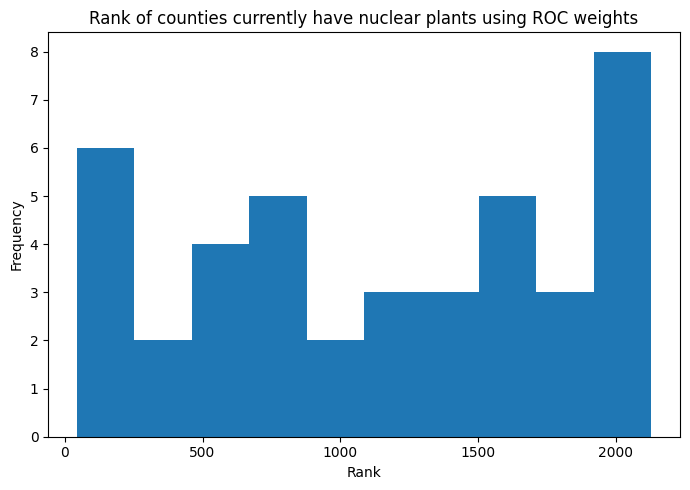

In [13]:
plt.figure(figsize = (7, 5))

plt.hist(
    x = df[df["has_plant"] == 1]["rank"]
)

plt.xlabel("Rank")
plt.ylabel("Frequency")
plt.title("Rank of counties currently have nuclear plants using ROC weights" \
"")
plt.tight_layout()

## Findings/Takeaways

- Our expert-driven scoring framework identifies the Great Lakes region (Michigan - FIP Code 26, Wisconsin FIP Code 55) as the most suitable area for nuclear reactor siting, drivne by low seismic risk, minimal flood risks, and cooling water resources

- None of the top-ranked counties by our scoring have existing plants, and plant counties are spread across full ranking distribution (see histogram above)

- This finding indicates a criteria difference between modern and historical sites

- **Next step**: investigate this difference using **supervised ML models**; explore the feature importance among historical sties and compare against our framework to see how the siting philosophy has shifted